# 0. Imports y Configuración
En esta sección se cargan las librerías necesarias y se definen las rutas y parámetros generales del procesamiento, como el video de entrada, la cantidad de frames por segundo, el intervalo del video y las carpetas de salida.

In [20]:
import math
import os
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyiqa
import seaborn as sns
import torch

from scipy import stats
from skimage.restoration import estimate_sigma
from tqdm import tqdm

import shutil
import tifffile
import re

from careamics import CAREamist
from careamics.config import create_n2n_config
from scipy.spatial.distance import squareform
from sklearn.cluster import AgglomerativeClustering

In [23]:
# Ruta del video que se desea procesar
RUTA_VIDEO = Path("Videos") / "video30min-11to22.mp4"

# Cantidad de imágenes que se extraerán por cada segundo de video
FRAMES_POR_SEGUNDO = 5.0

# Intervalo opcional del video
# None significa comenzar desde el inicio o terminar al final
SEGUNDO_INICIO = None
SEGUNDO_FIN = None

# Compresión PNG entre 0 y 9
COMPRESION_PNG = 3

# Carpeta donde se guardarán los frames
CARPETA_FRAMES = RUTA_VIDEO.parent / RUTA_VIDEO.stem / "frames"

# Semilla para obtener el mismo muestreo en cada ejecución
SEMILLA = 42

# Dispositivo para calcular NIQE y BRISQUE
DISPOSITIVO = "cuda" if torch.cuda.is_available() else "cpu"

# Carpeta donde se guardarán métricas, resúmenes y gráficas
CARPETA_METRICAS = RUTA_VIDEO.parent / RUTA_VIDEO.stem / "metricas"

# Archivo Excel donde se compararán todas las etapas del proyecto
RUTA_EXCEL_RESUMEN = CARPETA_METRICAS / "resumen.xlsx"

# Cantidad de píxeles tomados de cada frame para graficar el ruido
PIXELES_RUIDO_POR_FRAME = 10

# Resultados del análisis temporal
RUTA_DIAGNOSTICO_TEMPORAL = RUTA_VIDEO.parent / RUTA_VIDEO.stem / "diagnostico_temporal.csv"
RUTA_ANOMALIAS_TEMPORALES = RUTA_VIDEO.parent / RUTA_VIDEO.stem / "anomalias_temporales.csv"
RUTA_ESCENAS_TEMPORALES = RUTA_VIDEO.parent / RUTA_VIDEO.stem / "escenas_temporales.csv"

# Preparación y paralelización
LADO_ANALISIS = 640
MARGEN_ROI = 0.12
NUM_TRABAJADORES = min(8, os.cpu_count() or 1)

# Correspondencia geométrica
MIN_COINCIDENCIAS = 20
MIN_PROPORCION_INLIERS = 0.35
MIN_COBERTURA_PUNTOS = 0.03
CAMBIO_ESCALA_ZOOM = 0.04

# Anomalías y transiciones
FRACCION_FONDO_UNIFORME = 0.70
FACTOR_UMBRAL_ADAPTATIVO = 6
VENTANA_ESTABILIDAD = 3
UMBRAL_HS_ESTABLE = 0.18
UMBRAL_INTENSIDAD_ESTABLE = 0.12
MAX_EXTENSION_TRANSICION = 4

# Construcción de escenas
VENTANA_REFERENCIA = 5
PERSISTENCIA_CORTE = 3
MIN_FRAMES_ENTRE_CORTES = 12
UMBRAL_CAMBIO_ESCENA = 0.60

# 1. Extracción Frames

En esta sección se extrae una cantidad definida de frames por segundo, ya sea del video completo o de un fragmento específico. Cada frame se guarda en formato PNG con un nombre consecutivo.


In [3]:
captura = cv2.VideoCapture(str(RUTA_VIDEO))  # Abre el video AVI o MP4

if not captura.isOpened():
    raise RuntimeError(f"No se pudo abrir el video: {RUTA_VIDEO}")

fps_video = captura.get(cv2.CAP_PROP_FPS)  # Obtiene los FPS originales
total_frames = int(captura.get(cv2.CAP_PROP_FRAME_COUNT))  # Obtiene el total de frames

if not np.isfinite(fps_video) or fps_video <= 0 or total_frames <= 0:
    captura.release()
    raise RuntimeError(f"No se pudieron leer los metadatos de: {RUTA_VIDEO}")

duracion = total_frames / fps_video  # Calcula la duración en segundos

inicio = 0.0 if SEGUNDO_INICIO is None else max(0.0, float(SEGUNDO_INICIO))
fin = duracion if SEGUNDO_FIN is None else min(float(SEGUNDO_FIN), duracion)

if fin <= inicio:
    captura.release()
    raise ValueError("SEGUNDO_FIN debe ser mayor que SEGUNDO_INICIO")

if not 0 < FRAMES_POR_SEGUNDO <= fps_video:
    captura.release()
    raise ValueError(f"FRAMES_POR_SEGUNDO debe estar entre 0 y {fps_video:.3f}")

intervalo = 1 / FRAMES_POR_SEGUNDO  # Calcula los segundos entre cada frame
cantidad_salida = math.ceil((fin - inicio) * FRAMES_POR_SEGUNDO)
cantidad_digitos = max(1, len(str(cantidad_salida - 1)))

CARPETA_FRAMES.mkdir(parents=True, exist_ok=True)  # Crea la carpeta de salida

for indice in tqdm(range(cantidad_salida), desc=f"Extrayendo {RUTA_VIDEO.name}", unit="frame"):
    segundo = inicio + indice * intervalo
    indice_video = min(round(segundo * fps_video), total_frames - 1)

    captura.set(cv2.CAP_PROP_POS_FRAMES, indice_video)
    lectura_correcta, frame = captura.read()

    if not lectura_correcta or frame is None:
        captura.release()
        raise RuntimeError(f"No se pudo leer el segundo {segundo:.2f}")

    nombre = f"{indice:0{cantidad_digitos}d}.png"
    ruta_salida = CARPETA_FRAMES / nombre

    if not cv2.imwrite(str(ruta_salida), frame, [cv2.IMWRITE_PNG_COMPRESSION, COMPRESION_PNG]):
        captura.release()
        raise RuntimeError(f"No se pudo guardar: {ruta_salida}")

captura.release()

print(f"Extracción terminada: {cantidad_salida} frames guardados en {CARPETA_FRAMES}")

Extrayendo frames: 100%|██████████| 3300/3300 [21:03<00:00,  2.61frame/s]

Extracción terminada: 3300 frames guardados en Videos/video30min-11to22/Frames


# 2. Caracterización Calidad

Se calcularán métricas no referenciales para establecer la calidad inicial de los frames antes del procesamiento.

- **NIQE (↓):** Evalúa la calidad general del frame a partir de características propias de imágenes naturales; valores menores suelen indicar mejor calidad.

- **BRISQUE (↓):** Estima la degradación visual mediante características espaciales de la imagen; valores menores suelen indicar mejor calidad.

- **Ruido Estimado $\hat{\sigma}$ (↓):** Aproxima la intensidad del ruido mediante componentes de alta frecuencia; valores menores indican menos ruido estimado.

- **SNR Estimado (↑):** Compara la potencia de una versión suavizada del frame con la potencia de la diferencia respecto al original, mediante $\mathrm{SNR}=10\log_{10}(P_{\mathrm{señal}}/P_{\mathrm{ruido}})$; valores mayores indican una mejor relación señal-ruido.

- **Curtosis:** Mide la presencia de valores extremos en la diferencia entre el frame original y su versión suavizada; valores altos pueden ser compatibles con ruido impulsivo.

La diferencia se calcula como $R=I-\hat{I}$, donde $I$ es el frame original y $\hat{I}$ es su versión suavizada. Esta diferencia se utiliza como una aproximación del ruido, aunque también puede contener bordes y texturas.

Calculando métricas: 100%|██████████| 3300/3300 [16:48<00:00,  3.27frame/s]


,metrica,cantidad,media,desviacion_estandar,minimo,percentil_25,mediana,percentil_75,maximo
0,niqe,3300.0,6.028151,1.480470,4.103239e+00,5.210226,5.766099,6.416229,18.256645
1,brisque,3300.0,48.231233,13.228705,2.741718e+01,39.240143,45.850464,53.150970,104.798645
2,ruido_estimado_sigma,3300.0,0.359060,0.157820,2.623343e-15,0.264680,0.377304,0.463320,0.809135
3,snr_estimado_db,3300.0,25.947551,3.154790,7.802943e+00,24.520307,25.975214,27.828485,34.610303
4,curtosis,3300.0,61.868661,29.848054,2.120243e+01,42.808155,53.162640,70.623405,291.100555
5,intensidad_media,3300.0,95.099575,32.220196,1.821164e+00,75.320108,90.756882,112.243654,248.793945
6,contraste,3300.0,54.734800,14.936935,1.004367e+01,44.228348,53.870657,66.040609,113.110435


,metrica,baseline
0,niqe,6.028151
1,brisque,48.231233
2,ruido_estimado_sigma,0.359060
3,snr_estimado_db,25.947551
4,curtosis,61.868661
5,intensidad_media,95.099575
6,contraste,54.734800


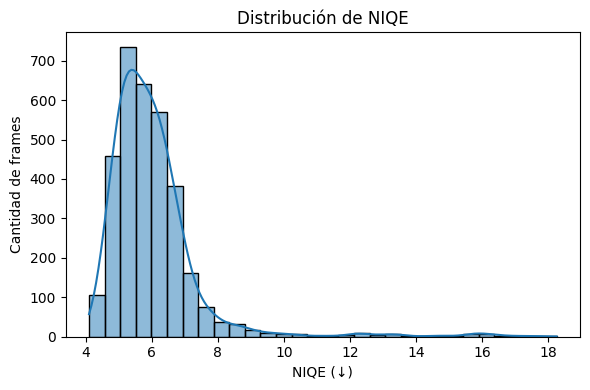

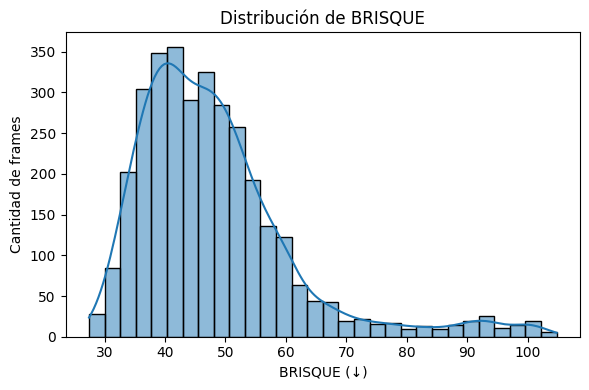

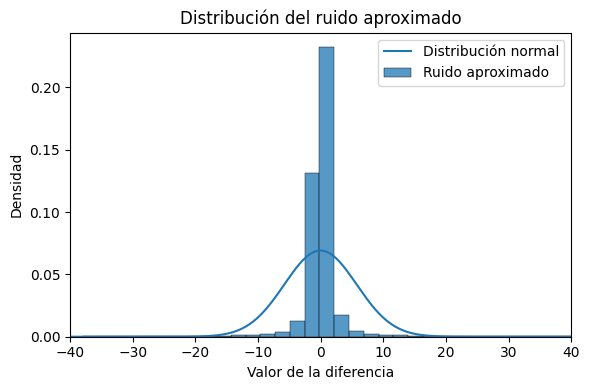

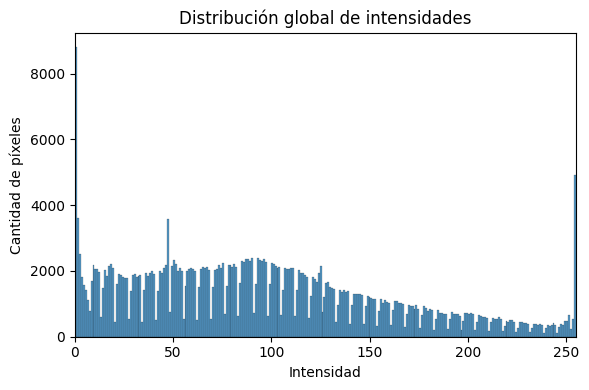

Excel de métricas guardado en: Videos/video30min-11to22/metricas/metricas_baseline.xlsx
Resumen de etapas guardado en: Videos/video30min-11to22/metricas/resumen.xlsx
Gráficas guardadas en: Videos/video30min-11to22/metricas
Frames analizados: 3300
Píxeles usados en la gráfica de ruido: 330000
Píxeles usados en la gráfica de intensidad: 330000


In [3]:
ETAPA = "baseline"

CARPETA_METRICAS.mkdir(parents=True, exist_ok=True)  # Crea la carpeta de métricas
ruta_excel_metricas = CARPETA_METRICAS / f"metricas_{ETAPA}.xlsx"  # Define el Excel detallado de la etapa

rutas_frames = sorted(ruta for ruta in CARPETA_FRAMES.iterdir() if ruta.suffix.lower() == ".png")  # Obtiene los frames en orden
metrica_niqe = pyiqa.create_metric("niqe", device=DISPOSITIVO)  # Prepara NIQE
metrica_brisque = pyiqa.create_metric("brisque", device=DISPOSITIVO)  # Prepara BRISQUE
generador = np.random.default_rng(SEMILLA)  # Permite repetir la misma selección de píxeles

resultados = []
muestras_ruido = []
muestras_intensidad = []

with torch.inference_mode():  # Evita cálculos de entrenamiento innecesarios
    for ruta_frame in tqdm(rutas_frames, desc="Calculando métricas", unit="frame"):
        frame_bgr = cv2.imread(str(ruta_frame), cv2.IMREAD_COLOR)  # Lee el frame

        if frame_bgr is not None:
            gris = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)  # Convierte el frame a gris
            niqe = float(metrica_niqe(str(ruta_frame)).item())  # Calcula NIQE
            brisque = float(metrica_brisque(str(ruta_frame)).item())  # Calcula BRISQUE
            ruido_estimado = float(estimate_sigma(gris / 255.0, channel_axis=None, average_sigmas=True) * 255.0)  # Estima la intensidad del ruido

            frame_suavizado = cv2.GaussianBlur(gris, (0, 0), sigmaX=1.5, sigmaY=1.5)  # Aproxima la parte principal de la imagen
            ruido_aproximado = gris - frame_suavizado  # Calcula la diferencia usada para aproximar el ruido
            ruido_vector = ruido_aproximado.ravel()  # Organiza los valores del ruido en una sola dimensión

            potencia_senal = float(np.mean(np.square(frame_suavizado)))  # Calcula la potencia de la señal aproximada
            potencia_ruido = float(np.mean(np.square(ruido_vector)))  # Calcula la potencia del ruido aproximado
            potencia_ruido = max(potencia_ruido, np.finfo(float).eps)  # Evita dividir entre cero
            snr_estimado = float(10.0 * np.log10(potencia_senal / potencia_ruido))  # Calcula el SNR estimado en decibelios
            curtosis = float(stats.kurtosis(ruido_vector, fisher=True, bias=False))  # Mide la presencia de valores extremos
            intensidad_media = float(gris.mean())  # Calcula el brillo promedio del frame
            contraste = float(gris.std())  # Calcula la dispersión de intensidades usada como medida de contraste

            cantidad_pixeles = min(PIXELES_RUIDO_POR_FRAME, gris.size)  # Limita los píxeles usados en las gráficas
            indices_ruido = generador.choice(ruido_vector.size, size=cantidad_pixeles, replace=False)  # Selecciona píxeles de ruido sin repetir
            indices_intensidad = generador.choice(gris.size, size=cantidad_pixeles, replace=False)  # Selecciona píxeles de intensidad sin repetir
            muestras_ruido.append(ruido_vector[indices_ruido])  # Guarda la muestra de ruido del frame
            muestras_intensidad.append(gris.ravel()[indices_intensidad])  # Guarda la muestra de intensidades del frame

            indice_frame = int(ruta_frame.stem)
            segundo_video = (0.0 if SEGUNDO_INICIO is None else SEGUNDO_INICIO) + indice_frame / FRAMES_POR_SEGUNDO  # Calcula el tiempo correspondiente al frame
            resultados.append({"frame": ruta_frame.name, "segundo_video": segundo_video, "niqe": niqe, "brisque": brisque, "ruido_estimado_sigma": ruido_estimado, "snr_estimado_db": snr_estimado, "curtosis": curtosis, "intensidad_media": intensidad_media, "contraste": contraste})
        else:
            print(f"No se pudo leer {ruta_frame.name}")

df_metricas = pd.DataFrame(resultados)  # Organiza las métricas por frame
columnas_metricas = ["niqe", "brisque", "ruido_estimado_sigma", "snr_estimado_db", "curtosis", "intensidad_media", "contraste"]  # Define las métricas que se resumirán

resumen_metricas = df_metricas[columnas_metricas].describe().T.reset_index()  # Calcula la estadística descriptiva de la etapa
resumen_metricas = resumen_metricas.rename(columns={"index": "metrica", "count": "cantidad", "mean": "media", "std": "desviacion_estandar", "min": "minimo", "25%": "percentil_25", "50%": "mediana", "75%": "percentil_75", "max": "maximo"})

with pd.ExcelWriter(ruta_excel_metricas, engine="openpyxl") as escritor:  # Guarda las métricas detalladas y su estadística descriptiva
    df_metricas.to_excel(escritor, sheet_name="metricas_por_frame", index=False)
    resumen_metricas.to_excel(escritor, sheet_name="estadistica_descriptiva", index=False)

resumen_etapa = df_metricas[columnas_metricas].mean().rename(ETAPA)  # Calcula el valor global de cada métrica para la etapa

if RUTA_EXCEL_RESUMEN.exists():
    resumen_global = pd.read_excel(RUTA_EXCEL_RESUMEN).set_index("metrica")  # Carga las etapas calculadas anteriormente
    resumen_global = resumen_global.reindex(resumen_global.index.union(resumen_etapa.index, sort=False))  # Incorpora métricas nuevas sin eliminar las existentes
    resumen_global[ETAPA] = resumen_etapa  # Agrega o actualiza la columna de la etapa actual
else:
    resumen_global = resumen_etapa.to_frame()  # Crea el resumen cuando todavía no existen otras etapas

resumen_global.index.name = "metrica"  # Nombra la columna que contiene las métricas
resumen_global.reset_index().to_excel(RUTA_EXCEL_RESUMEN, index=False)  # Guarda la comparación global entre etapas

display(resumen_metricas)  # Muestra la estadística descriptiva en el notebook
display(resumen_global.reset_index())  # Muestra la comparación global entre etapas

valores_ruido = np.concatenate(muestras_ruido)  # Une las muestras de ruido de todos los frames
valores_intensidad = np.concatenate(muestras_intensidad)  # Une las muestras de intensidad de todos los frames
media_ruido = float(valores_ruido.mean())
desviacion_ruido = float(valores_ruido.std())
limite_ruido = float(np.percentile(np.abs(valores_ruido), 99.5))  # Limita la gráfica al rango que contiene el 99.5 % de las magnitudes
eje_normal = np.linspace(-limite_ruido, limite_ruido, 300)  # Crea los valores usados para representar la distribución normal
densidad_normal = stats.norm.pdf(eje_normal, loc=media_ruido, scale=desviacion_ruido)  # Calcula la función de densidad de una normal equivalente

figura, eje = plt.subplots(figsize=(6, 4))  # Crea la gráfica de NIQE
sns.histplot(data=df_metricas, x="niqe", bins=30, kde=True, ax=eje)
eje.set_title("Distribución de NIQE")
eje.set_xlabel("NIQE (↓)")
eje.set_ylabel("Cantidad de frames")
figura.tight_layout()  # Ajusta los márgenes al contenido
figura.savefig(str(CARPETA_METRICAS / f"niqe_{ETAPA}.png"), dpi=300, bbox_inches="tight")  # Guarda la gráfica con alta resolución
plt.show()

figura, eje = plt.subplots(figsize=(6, 4))  # Crea la gráfica de BRISQUE
sns.histplot(data=df_metricas, x="brisque", bins=30, kde=True, ax=eje)
eje.set_title("Distribución de BRISQUE")
eje.set_xlabel("BRISQUE (↓)")
eje.set_ylabel("Cantidad de frames")
figura.tight_layout()  # Ajusta los márgenes al contenido
figura.savefig(str(CARPETA_METRICAS / f"brisque_{ETAPA}.png"), dpi=300, bbox_inches="tight")  # Guarda la gráfica con alta resolución
plt.show()

figura, eje = plt.subplots(figsize=(6, 4))  # Crea la gráfica del ruido aproximado
sns.histplot(valores_ruido, bins=100, stat="density", label="Ruido aproximado", ax=eje)
eje.plot(eje_normal, densidad_normal, label="Distribución normal")
eje.set_xlim(-limite_ruido, limite_ruido)
eje.set_title("Distribución del ruido aproximado")
eje.set_xlabel("Valor de la diferencia")
eje.set_ylabel("Densidad")
eje.legend()
figura.tight_layout()  # Ajusta los márgenes al contenido
figura.savefig(str(CARPETA_METRICAS / f"ruido_{ETAPA}.png"), dpi=300, bbox_inches="tight")  # Guarda la gráfica con alta resolución
plt.show()

figura, eje = plt.subplots(figsize=(6, 4))  # Crea la gráfica global de intensidades
sns.histplot(valores_intensidad, bins=256, binrange=(0, 255), ax=eje)
eje.set_xlim(0, 255)
eje.set_title("Distribución global de intensidades")
eje.set_xlabel("Intensidad")
eje.set_ylabel("Cantidad de píxeles")
figura.tight_layout()  # Ajusta los márgenes al contenido
figura.savefig(str(CARPETA_METRICAS / f"intensidad_{ETAPA}.png"), dpi=300, bbox_inches="tight")  # Guarda la gráfica con alta resolución
plt.show()

print(f"Excel de métricas guardado en: {ruta_excel_metricas}")
print(f"Resumen de etapas guardado en: {RUTA_EXCEL_RESUMEN}")
print(f"Gráficas guardadas en: {CARPETA_METRICAS}")
print(f"Frames analizados: {len(df_metricas)}")
print(f"Píxeles usados en la gráfica de ruido: {len(valores_ruido)}")
print(f"Píxeles usados en la gráfica de intensidad: {len(valores_intensidad)}")

# 3. Denoising Original
## 3.1. Noise2Noise
Noise2Noise aprende a reducir ruido usando dos observaciones ruidosas del mismo contenido. En este experimento, cada ejemplo se construye con dos frames consecutivos: el primero se usa como entrada y el segundo como objetivo.

Para evitar fuga de datos, lo primero que haremos es dividir los frames del vídeo en escenas. Una escena es un segmento temporal continuo sin cambios abruptos de contenido, modalidad o zoom. Para detectar esos cambios se usa un **histograma H-S**, que resume la distribución de tono (*Hue*) y saturación (*Saturation*) de cada frame. Esta representación prioriza los colores y reduce la influencia directa del brillo.

Cuando la distancia de Bhattacharyya (diferencia entre histogramas) entre dos frames consecutivos alcanza el `UMBRAL_CORTE`, se crea un límite de escena. Luego, los dos frames a cada lado del corte se marcan con `_transicion` y se conservan únicamente para revisión. Después, las escenas completas se comparan entre sí y las visualmente similares se reúnen en un mismo grupo para evitar repartir contenido casi duplicado entre train, valid y test.

Comparando frames consecutivos: 100%|██████████| 3299/3299 [01:21<00:00, 40.66par/s]


Escenas: 133
Frames válidos: 2698
Anomalías totales: 602
Transiciones excluidas: 574
Zooms excluidos: 28
Cambios de encuadre conservados: 5


,escena,frame_inicial,frame_final,indice_inicial,indice_final,cantidad_frames
0,escena_1,0000.png,0011.png,0,11,12
1,escena_2,0016.png,0032.png,16,32,17
2,escena_3,0051.png,0083.png,51,83,33
3,escena_4,0086.png,0094.png,86,94,9
4,escena_5,0104.png,0112.png,104,112,9
...,...,...,...,...,...,...
128,escena_129,3135.png,3165.png,3135,3165,31
129,escena_130,3169.png,3188.png,3169,3188,20
130,escena_131,3197.png,3227.png,3197,3227,31
131,escena_132,3233.png,3295.png,3233,3295,63


,indice,frame,clasificacion,razon,frame_anterior,distancia_hs,distancia_hs_siguiente,diferencia_intensidad,diferencia_intensidad_siguiente,diferencia_saturacion,diferencia_saturacion_siguiente,coincidencias,proporcion_inliers,cobertura_puntos,escala,contraste,entropia,fraccion_blanca,fraccion_negra,artefactos_bloques
12,12,0012.png,transicion,difiere_del_anterior_y_del_siguiente,0011.png,0.866994,0.898729,0.230398,0.191390,0.346757,0.462438,0.0,0.000000,0.000000,NaN,20.919906,6.128533,0.000000,0.000023,0.657829
13,13,0013.png,transicion,cola_transicion_inestable,0012.png,0.898729,0.207574,0.191390,0.092106,0.462438,0.106257,0.0,0.000000,0.000000,NaN,47.007610,7.416510,0.000120,0.057583,6.845830
14,14,0014.png,transicion,cola_transicion_inestable,0013.png,0.207574,0.305427,0.092106,0.037565,0.106257,0.125206,335.0,0.761194,0.629524,1.000461,49.845115,7.604578,0.003484,0.014486,10.081015
15,15,0015.png,transicion,cola_transicion_inestable,0014.png,0.305427,0.191226,0.037565,0.106691,0.125206,0.012988,905.0,0.943646,0.649785,1.000104,50.194476,7.627653,0.005760,0.010611,11.848526
33,33,0033.png,transicion,fondo_negro;frame_uniforme,0032.png,0.942593,0.994139,0.321057,0.438579,0.150758,0.030199,0.0,0.000000,0.318449,NaN,5.181736,0.274602,0.000000,0.994143,0.316209
34,34,0034.png,transicion,difiere_del_anterior_y_del_siguiente,0033.png,0.994139,0.992519,0.438579,0.556171,0.030199,0.185596,0.0,0.000000,0.000000,NaN,8.821520,5.102809,0.000000,0.000000,2.375667
35,35,0035.png,transicion,fondo_blanco;frame_uniforme,0034.png,0.992519,0.903785,0.556171,0.716031,0.185596,0.335630,0.0,0.000000,0.000000,NaN,11.290922,0.276129,0.989141,0.000000,0.676098
36,36,0036.png,transicion,cola_transicion_inestable,0035.png,0.903785,0.341330,0.716031,0.100068,0.335630,0.106210,0.0,0.000000,0.000000,NaN,49.922028,7.334401,0.001690,0.116743,6.474832
37,37,0037.png,transicion,cola_transicion_inestable,0036.png,0.341330,0.132731,0.100068,0.062848,0.106210,0.029990,242.0,0.859504,0.497432,0.999014,50.342193,7.581133,0.002478,0.032141,7.285343
38,38,0038.png,transicion,cola_transicion_inestable,0037.png,0.132731,0.166680,0.062848,0.059292,0.029990,0.023127,99.0,0.747475,0.593118,1.007919,50.657312,7.593228,0.004521,0.017107,7.875977


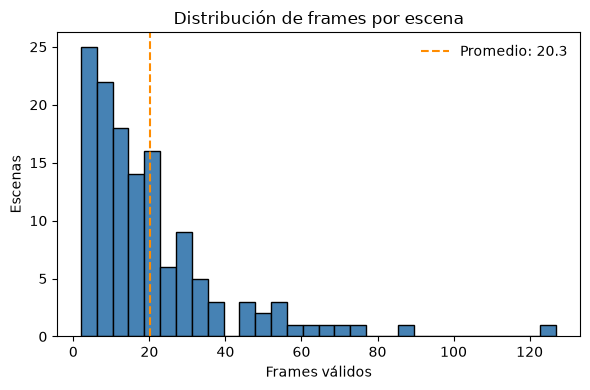

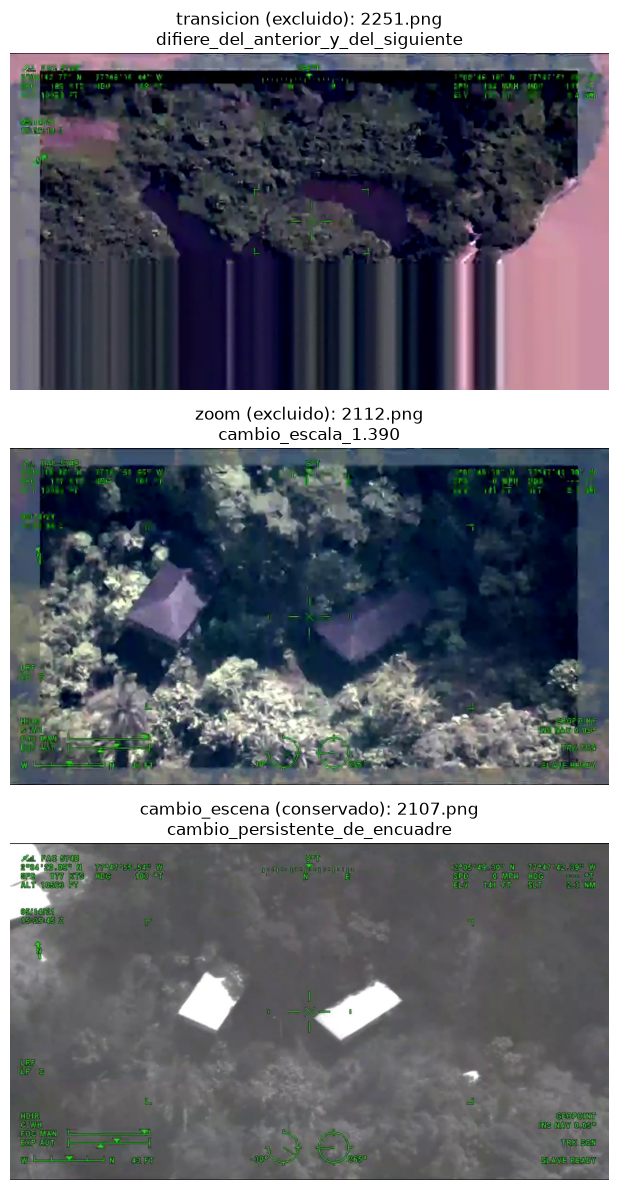

In [ ]:
rutas_frames = sorted(CARPETA_FRAMES.glob("*.png"), key=lambda ruta: [int(parte) if parte.isdigit() else parte for parte in re.split(r"(\d+)", ruta.name)])

if len(rutas_frames) < 3:
    raise ValueError("Se necesitan al menos tres frames para analizar la continuidad temporal.")


def preparar_frame(ruta):
    imagen = cv2.imread(str(ruta), cv2.IMREAD_COLOR)

    if imagen is None:
        raise RuntimeError(f"No se pudo leer {ruta.name}")

    alto, ancho = imagen.shape[:2]
    escala = min(1.0, LADO_ANALISIS / max(alto, ancho))

    if escala < 1.0:
        imagen = cv2.resize(imagen, (round(ancho * escala), round(alto * escala)), interpolation=cv2.INTER_AREA)

    alto, ancho = imagen.shape[:2]
    margen_y = round(alto * MARGEN_ROI)
    margen_x = round(ancho * MARGEN_ROI)

    return imagen[margen_y:alto - margen_y, margen_x:ancho - margen_x]


def calcular_histograma_hs(imagen):
    hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
    histograma = cv2.calcHist([hsv], [0, 1], None, [32, 32], [0, 180, 0, 256]).astype(np.float32)
    cv2.normalize(histograma, histograma, alpha=1, norm_type=cv2.NORM_L1)

    return histograma


def calcular_metricas_frame(ruta):
    roi = preparar_frame(ruta)
    gris = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    histograma_gris = cv2.calcHist([gris], [0], None, [256], [0, 256]).ravel()
    probabilidades = histograma_gris / max(histograma_gris.sum(), 1)
    entropia = float(stats.entropy(probabilidades[probabilidades > 0], base=2))

    bordes = cv2.Canny(gris, 60, 160)
    gradiente_vertical = np.abs(np.diff(gris.astype(np.float32), axis=0))
    gradiente_horizontal = np.abs(np.diff(gris.astype(np.float32), axis=1))

    franjas_horizontales = float(np.percentile(gradiente_vertical.mean(axis=1), 95))
    franjas_verticales = float(np.percentile(gradiente_horizontal.mean(axis=0), 95))

    bloques_h = np.abs(gris[:, 8::8].astype(np.float32) - gris[:, 7::8].astype(np.float32))
    bloques_v = np.abs(gris[8::8, :].astype(np.float32) - gris[7::8, :].astype(np.float32))
    artefactos_bloques = float(bloques_h.mean() + bloques_v.mean()) if bloques_h.size and bloques_v.size else 0.0

    return {
        "intensidad_media": float(gris.mean()),
        "contraste": float(gris.std()),
        "entropia": entropia,
        "fraccion_blanca": float((gris >= 245).mean()),
        "fraccion_negra": float((gris <= 10).mean()),
        "densidad_bordes": float((bordes > 0).mean()),
        "franjas_horizontales": franjas_horizontales,
        "franjas_verticales": franjas_verticales,
        "artefactos_bloques": artefactos_bloques,
        "histograma_hs": calcular_histograma_hs(roi),
    }


def calcular_metricas_par(argumentos):
    indice, ruta_anterior, ruta_actual = argumentos

    anterior = preparar_frame(ruta_anterior)
    actual = preparar_frame(ruta_actual)

    gris_anterior = cv2.cvtColor(anterior, cv2.COLOR_BGR2GRAY)
    gris_actual = cv2.cvtColor(actual, cv2.COLOR_BGR2GRAY)
    hsv_anterior = cv2.cvtColor(anterior, cv2.COLOR_BGR2HSV)
    hsv_actual = cv2.cvtColor(actual, cv2.COLOR_BGR2HSV)

    histograma_anterior = calcular_histograma_hs(anterior)
    histograma_actual = calcular_histograma_hs(actual)

    distancia_hs = float(cv2.compareHist(histograma_anterior, histograma_actual, cv2.HISTCMP_BHATTACHARYYA))
    diferencia_intensidad = float(cv2.absdiff(gris_anterior, gris_actual).mean() / 255)
    diferencia_saturacion = float(abs(float(hsv_actual[:, :, 1].mean()) - float(hsv_anterior[:, :, 1].mean())) / 255)

    orb = cv2.ORB_create(nfeatures=2000, fastThreshold=12)
    comparador = cv2.BFMatcher(cv2.NORM_HAMMING)

    puntos_anterior, descriptores_anterior = orb.detectAndCompute(cv2.equalizeHist(gris_anterior), None)
    puntos_actual, descriptores_actual = orb.detectAndCompute(cv2.equalizeHist(gris_actual), None)

    coincidencias = 0
    proporcion_inliers = 0.0
    cobertura_puntos = 0.0
    escala = np.nan

    if descriptores_anterior is not None and descriptores_actual is not None:
        coincidencias_knn = comparador.knnMatch(descriptores_anterior, descriptores_actual, k=2)
        buenas = [pareja[0] for pareja in coincidencias_knn if len(pareja) == 2 and pareja[0].distance < 0.75 * pareja[1].distance]

        if len(buenas) >= 12:
            origen = np.float32([puntos_anterior[coincidencia.queryIdx].pt for coincidencia in buenas])
            destino = np.float32([puntos_actual[coincidencia.trainIdx].pt for coincidencia in buenas])
            transformacion, mascara = cv2.estimateAffinePartial2D(origen, destino, method=cv2.RANSAC, ransacReprojThreshold=3.0)

            if transformacion is not None and mascara is not None:
                alto_roi, ancho_roi = gris_anterior.shape
                _, _, ancho_puntos, alto_puntos = cv2.boundingRect(origen)
                cobertura_puntos = float((ancho_puntos * alto_puntos) / (ancho_roi * alto_roi))
                escala_estimada = float(np.sqrt(transformacion[0, 0] ** 2 + transformacion[0, 1] ** 2))

                if 0.5 <= escala_estimada <= 2.0 and cobertura_puntos >= MIN_COBERTURA_PUNTOS:
                    coincidencias = len(buenas)
                    proporcion_inliers = float(mascara.mean())
                    escala = escala_estimada

    return {
        "indice": indice,
        "frame_anterior": ruta_anterior.name,
        "frame": ruta_actual.name,
        "distancia_hs": distancia_hs,
        "diferencia_intensidad": diferencia_intensidad,
        "diferencia_saturacion": diferencia_saturacion,
        "coincidencias": coincidencias,
        "proporcion_inliers": proporcion_inliers,
        "cobertura_puntos": cobertura_puntos,
        "escala": escala,
    }


# Calcula las características individuales de los frames en paralelo
with ThreadPoolExecutor(max_workers=NUM_TRABAJADORES) as ejecutor:
    resultados_frames = list(
        tqdm(
            ejecutor.map(calcular_metricas_frame, rutas_frames),
            total=len(rutas_frames),
            desc="Analizando frames",
            unit="frame",
            mininterval=2.0,
        )
    )

metricas_frames = []

for indice, (ruta, metricas) in enumerate(zip(rutas_frames, resultados_frames)):
    metricas_frames.append({"indice": indice, "frame": ruta.name, **metricas})

df_frames = pd.DataFrame(metricas_frames)

# Compara todos los pares consecutivos en paralelo
argumentos_pares = [(indice, rutas_frames[indice - 1], rutas_frames[indice]) for indice in range(1, len(rutas_frames))]

with ThreadPoolExecutor(max_workers=NUM_TRABAJADORES) as ejecutor:
    metricas_pares = list(
        tqdm(
            ejecutor.map(calcular_metricas_par, argumentos_pares),
            total=len(argumentos_pares),
            desc="Comparando frames consecutivos",
            unit="par",
            mininterval=2.0,
        )
    )

df_diagnostico = df_frames.merge(pd.DataFrame(metricas_pares), on=["indice", "frame"], how="left")

# La métrica de la fila actual describe la comparación con el frame anterior.
# El desplazamiento permite consultar también la comparación con el frame siguiente.
for columna in ["distancia_hs", "diferencia_intensidad", "diferencia_saturacion", "coincidencias", "proporcion_inliers"]:
    df_diagnostico[f"{columna}_siguiente"] = df_diagnostico[columna].shift(-1)

columnas_adaptativas = [
    "distancia_hs",
    "diferencia_intensidad",
    "diferencia_saturacion",
    "franjas_horizontales",
    "franjas_verticales",
    "artefactos_bloques",
]

umbrales = {}

for columna in columnas_adaptativas:
    valores = df_diagnostico[columna].dropna()
    mediana = valores.median()
    mad = np.median(np.abs(valores - mediana))
    umbrales[columna] = mediana + FACTOR_UMBRAL_ADAPTATIVO * mad

umbrales["distancia_hs"] = max(0.35, umbrales["distancia_hs"])
umbrales["diferencia_intensidad"] = max(0.15, umbrales["diferencia_intensidad"])
umbrales["diferencia_saturacion"] = max(0.12, umbrales["diferencia_saturacion"])

df_diagnostico["es_anomalia"] = False
df_diagnostico["corte_escena"] = False
df_diagnostico["clasificacion"] = "valido"
df_diagnostico["razon"] = "continuidad"

# Detecta frames anómalos por sus propias características
for indice, fila in df_diagnostico.iterrows():
    razones = []

    if fila["fraccion_blanca"] >= FRACCION_FONDO_UNIFORME:
        razones.append("fondo_blanco")

    if fila["fraccion_negra"] >= FRACCION_FONDO_UNIFORME:
        razones.append("fondo_negro")

    if fila["contraste"] <= 8 or fila["entropia"] <= 3:
        razones.append("frame_uniforme")

    if fila["franjas_horizontales"] >= umbrales["franjas_horizontales"] or fila["franjas_verticales"] >= umbrales["franjas_verticales"]:
        razones.append("artefactos_franjas")

    if fila["artefactos_bloques"] >= umbrales["artefactos_bloques"] and fila["entropia"] < 6:
        razones.append("artefactos_bloques")

    if razones:
        df_diagnostico.loc[indice, ["es_anomalia", "clasificacion", "razon"]] = [
            True,
            "transicion",
            ";".join(razones),
        ]

# Evalúa el primer frame, que no tiene comparación con un frame anterior
cambio_inicio = (
    df_diagnostico.loc[0, "distancia_hs_siguiente"] >= umbrales["distancia_hs"]
    or df_diagnostico.loc[0, "diferencia_intensidad_siguiente"] >= umbrales["diferencia_intensidad"]
)

estabilidad_despues_inicio = (
    df_diagnostico.loc[1, "distancia_hs_siguiente"] <= UMBRAL_HS_ESTABLE
    and df_diagnostico.loc[1, "diferencia_intensidad_siguiente"] <= UMBRAL_INTENSIDAD_ESTABLE
)

if cambio_inicio and estabilidad_despues_inicio:
    df_diagnostico.loc[0, ["es_anomalia", "clasificacion", "razon"]] = [
        True,
        "transicion",
        "inicio_atipico",
    ]

# Detecta frames intermedios que son inestables respecto a ambos lados
for indice in range(1, len(df_diagnostico) - 1):
    if df_diagnostico.loc[indice, "es_anomalia"]:
        continue

    cambio_anterior = (
        df_diagnostico.loc[indice, "distancia_hs"] >= umbrales["distancia_hs"]
        or df_diagnostico.loc[indice, "diferencia_intensidad"] >= umbrales["diferencia_intensidad"]
    )

    cambio_siguiente = (
        df_diagnostico.loc[indice, "distancia_hs_siguiente"] >= umbrales["distancia_hs"]
        or df_diagnostico.loc[indice, "diferencia_intensidad_siguiente"] >= umbrales["diferencia_intensidad"]
    )

    saturacion_inestable = (
        df_diagnostico.loc[indice, "diferencia_saturacion"] >= umbrales["diferencia_saturacion"]
        and df_diagnostico.loc[indice, "diferencia_saturacion_siguiente"] >= umbrales["diferencia_saturacion"]
    )

    if cambio_anterior and cambio_siguiente:
        df_diagnostico.loc[indice, ["es_anomalia", "clasificacion", "razon"]] = [
            True,
            "transicion",
            "difiere_del_anterior_y_del_siguiente",
        ]
    elif saturacion_inestable:
        df_diagnostico.loc[indice, ["es_anomalia", "clasificacion", "razon"]] = [
            True,
            "transicion",
            "cambio_inestable_de_saturacion",
        ]

# Extiende una transición hasta encontrar una secuencia estable.
# La extensión es limitada para evitar absorber frames válidos de la escena siguiente.
indices_semilla = df_diagnostico.index[df_diagnostico["es_anomalia"]].tolist()

for semilla in indices_semilla:
    limite = min(len(df_diagnostico) - VENTANA_ESTABILIDAD - 1, semilla + MAX_EXTENSION_TRANSICION)

    for candidato in range(semilla + 1, limite + 1):
        inicio_ventana = candidato
        fin_ventana = candidato + VENTANA_ESTABILIDAD

        ventana_hs = df_diagnostico.loc[inicio_ventana:fin_ventana - 1, "distancia_hs_siguiente"]
        ventana_intensidad = df_diagnostico.loc[inicio_ventana:fin_ventana - 1, "diferencia_intensidad_siguiente"]
        ventana_anomalias = df_diagnostico.loc[inicio_ventana:fin_ventana, "es_anomalia"]

        estable = (
            not ventana_anomalias.any()
            and (ventana_hs <= UMBRAL_HS_ESTABLE).all()
            and (ventana_intensidad <= UMBRAL_INTENSIDAD_ESTABLE).all()
        )

        if estable:
            break

        if not df_diagnostico.loc[candidato, "es_anomalia"]:
            df_diagnostico.loc[candidato, ["es_anomalia", "clasificacion", "razon"]] = [
                True,
                "transicion",
                "cola_transicion_inestable",
            ]

# Un frame válido entre dos anomalías también pertenece al intervalo de transición
for indice in range(1, len(df_diagnostico) - 1):
    if (
        not df_diagnostico.loc[indice, "es_anomalia"]
        and df_diagnostico.loc[indice - 1, "es_anomalia"]
        and df_diagnostico.loc[indice + 1, "es_anomalia"]
    ):
        df_diagnostico.loc[indice, ["es_anomalia", "clasificacion", "razon"]] = [
            True,
            "transicion",
            "entre_frames_anomalos",
        ]

# Un zoom rápido es una anomalía y no debe formar parte de las escenas
for indice in range(1, len(df_diagnostico)):
    if df_diagnostico.loc[indice, "es_anomalia"]:
        continue

    fila = df_diagnostico.loc[indice]
    geometria_conservada = (
        fila["coincidencias"] >= MIN_COINCIDENCIAS
        and fila["proporcion_inliers"] >= MIN_PROPORCION_INLIERS
        and pd.notna(fila["escala"])
    )

    if geometria_conservada and abs(np.log(fila["escala"])) >= CAMBIO_ESCALA_ZOOM:
        df_diagnostico.loc[indice, ["es_anomalia", "clasificacion", "razon"]] = [
            True,
            "zoom",
            f"cambio_escala_{fila['escala']:.3f}",
        ]

# Una anomalía detectada después puede dejar un único frame válido en medio de dos anomalías
for indice in range(1, len(df_diagnostico) - 1):
    if (
        not df_diagnostico.loc[indice, "es_anomalia"]
        and df_diagnostico.loc[indice - 1, "es_anomalia"]
        and df_diagnostico.loc[indice + 1, "es_anomalia"]
    ):
        df_diagnostico.loc[indice, ["es_anomalia", "clasificacion", "razon"]] = [
            True,
            "transicion",
            "entre_frames_anomalos",
        ]

# Construye escenas usando anomalías y cambios persistentes de encuadre.
# El movimiento lento de cámara conserva los frames, pero puede iniciar una escena nueva.
escenas = []
inicio_escena = None
ultimo_corte = -MIN_FRAMES_ENTRE_CORTES
numero_escena = 1

for indice in range(len(df_diagnostico)):
    if df_diagnostico.loc[indice, "es_anomalia"]:
        if inicio_escena is not None:
            escenas.append({
                "escena": f"escena_{numero_escena}",
                "frame_inicial": rutas_frames[inicio_escena].name,
                "frame_final": rutas_frames[indice - 1].name,
                "indice_inicial": inicio_escena,
                "indice_final": indice - 1,
                "cantidad_frames": indice - inicio_escena,
            })

            numero_escena += 1
            inicio_escena = None

        continue

    if inicio_escena is None:
        inicio_escena = indice
        ultimo_corte = indice
        continue

    if indice - inicio_escena < MIN_FRAMES_ENTRE_CORTES:
        continue

    if indice - ultimo_corte < MIN_FRAMES_ENTRE_CORTES:
        continue

    if indice + PERSISTENCIA_CORTE >= len(df_diagnostico):
        continue

    if df_diagnostico.loc[indice:indice + PERSISTENCIA_CORTE - 1, "es_anomalia"].any():
        continue

    inicio_referencia = max(inicio_escena, indice - VENTANA_REFERENCIA)
    indices_referencia = [
        posicion
        for posicion in range(inicio_referencia, indice)
        if not df_diagnostico.loc[posicion, "es_anomalia"]
    ]

    if len(indices_referencia) < 2:
        continue

    histograma_referencia = np.mean(
        [df_frames.loc[posicion, "histograma_hs"] for posicion in indices_referencia],
        axis=0,
    ).astype(np.float32)

    distancias_futuras = [
        cv2.compareHist(
            histograma_referencia,
            df_frames.loc[posicion, "histograma_hs"],
            cv2.HISTCMP_BHATTACHARYYA,
        )
        for posicion in range(indice, indice + PERSISTENCIA_CORTE)
    ]

    cambio_persistente = all(distancia >= UMBRAL_CAMBIO_ESCENA for distancia in distancias_futuras)
    cambio_local_suave = df_diagnostico.loc[indice, "distancia_hs"] < umbrales["distancia_hs"]

    if cambio_persistente and cambio_local_suave:
        escenas.append({
            "escena": f"escena_{numero_escena}",
            "frame_inicial": rutas_frames[inicio_escena].name,
            "frame_final": rutas_frames[indice - 1].name,
            "indice_inicial": inicio_escena,
            "indice_final": indice - 1,
            "cantidad_frames": indice - inicio_escena,
        })

        df_diagnostico.loc[indice, ["corte_escena", "clasificacion", "razon"]] = [
            True,
            "cambio_escena",
            "cambio_persistente_de_encuadre",
        ]

        numero_escena += 1
        inicio_escena = indice
        ultimo_corte = indice

if inicio_escena is not None:
    escenas.append({
        "escena": f"escena_{numero_escena}",
        "frame_inicial": rutas_frames[inicio_escena].name,
        "frame_final": rutas_frames[-1].name,
        "indice_inicial": inicio_escena,
        "indice_final": len(rutas_frames) - 1,
        "cantidad_frames": len(rutas_frames) - inicio_escena,
    })

df_escenas = pd.DataFrame(escenas)
anomalias = df_diagnostico[df_diagnostico["es_anomalia"]].copy()

columnas_anomalias = [
    "indice",
    "frame",
    "clasificacion",
    "razon",
    "frame_anterior",
    "distancia_hs",
    "distancia_hs_siguiente",
    "diferencia_intensidad",
    "diferencia_intensidad_siguiente",
    "diferencia_saturacion",
    "diferencia_saturacion_siguiente",
    "coincidencias",
    "proporcion_inliers",
    "cobertura_puntos",
    "escala",
    "contraste",
    "entropia",
    "fraccion_blanca",
    "fraccion_negra",
    "artefactos_bloques",
]

# El histograma se utilizó internamente y no se guarda como texto dentro del CSV
df_diagnostico_exportar = df_diagnostico.drop(columns="histograma_hs")

df_diagnostico_exportar.to_csv(RUTA_DIAGNOSTICO_TEMPORAL, index=False)
anomalias[columnas_anomalias].to_csv(RUTA_ANOMALIAS_TEMPORALES, index=False)
df_escenas.to_csv(RUTA_ESCENAS_TEMPORALES, index=False)

print(f"Escenas: {len(df_escenas)}")
print(f"Frames válidos: {(~df_diagnostico['es_anomalia']).sum()}")
print(f"Anomalías totales: {df_diagnostico['es_anomalia'].sum()}")
print(f"Transiciones excluidas: {(df_diagnostico['clasificacion'] == 'transicion').sum()}")
print(f"Zooms excluidos: {(df_diagnostico['clasificacion'] == 'zoom').sum()}")
print(f"Cambios de encuadre conservados: {((df_diagnostico['clasificacion'] == 'cambio_escena') & ~df_diagnostico['es_anomalia']).sum()}")

display(df_escenas)
display(anomalias[columnas_anomalias].head(30))

if not df_escenas.empty:
    figura, eje = plt.subplots(figsize=(6, 4))
    eje.hist(df_escenas["cantidad_frames"], bins=min(30, len(df_escenas)), color="steelblue", edgecolor="black")
    eje.axvline(df_escenas["cantidad_frames"].mean(), color="darkorange", linestyle="--", label=f"Promedio: {df_escenas['cantidad_frames'].mean():.1f}")
    eje.set_title("Distribución de frames por escena")
    eje.set_xlabel("Frames válidos")
    eje.set_ylabel("Escenas")
    eje.legend(frameon=False)
    figura.tight_layout()
    plt.show()

ejemplos = []

for clase in ("transicion", "zoom", "cambio_escena"):
    candidatos = df_diagnostico[df_diagnostico["clasificacion"] == clase]

    if not candidatos.empty:
        puntaje = candidatos["distancia_hs"].fillna(0) + candidatos["diferencia_intensidad"].fillna(0)
        ejemplos.append(candidatos.loc[puntaje.idxmax()])

if ejemplos:
    figura, ejes = plt.subplots(len(ejemplos), 1, figsize=(7, 4 * len(ejemplos)), squeeze=False)

    for fila, eje in zip(ejemplos, ejes[:, 0]):
        imagen = cv2.cvtColor(cv2.imread(str(CARPETA_FRAMES / fila["frame"])), cv2.COLOR_BGR2RGB)
        estado = "excluido" if fila["es_anomalia"] else "conservado"
        eje.imshow(imagen)
        eje.set_title(f"{fila['clasificacion']} ({estado}): {fila['frame']}\n{fila['razon']}")
        eje.axis("off")

    figura.tight_layout()
    plt.show()

A continuación, los grupos visuales completos se asignan a train, valid o test. De este modo, dos escenas detectadas como muy parecidas nunca quedan en conjuntos diferentes.

Train y valid usan parejas deslizantes dentro de cada escena: `frame_t → frame_t+1`. Los TIFF conservan el nombre original del frame de entrada. Por ejemplo, `input/0000.tif` contiene `0000.png` y `target/0000.tif` contiene el frame consecutivo `0001.png`. La correspondencia también queda registrada en `parejas.csv`.

Test no necesita parejas, contiene únicamente los frames originales que se utilizarán para inferencia y evaluación.

In [5]:
grupos_visuales = {}
for escena in escenas:
    grupos_visuales.setdefault(escena["grupo_visual"], []).append(escena)
if len(grupos_visuales) < 3:
    raise ValueError("Se necesitan al menos tres grupos visuales. Reduzca UMBRAL_GRUPO_VISUAL.")

total_frames = sum(len(escena["indices"]) for escena in escenas)
objetivos = {nombre: proporcion * total_frames for nombre, proporcion in PROPORCIONES.items()}
asignaciones = {nombre: [] for nombre in PROPORCIONES}
totales = {nombre: 0 for nombre in PROPORCIONES}
grupos_ordenados = sorted(grupos_visuales.items(), key=lambda item: sum(len(escena["indices"]) for escena in item[1]), reverse=True)

for nombre, (grupo, escenas_grupo) in zip(PROPORCIONES, grupos_ordenados[:3]):
    asignaciones[nombre].append(grupo)
    totales[nombre] += sum(len(escena["indices"]) for escena in escenas_grupo)
for grupo, escenas_grupo in grupos_ordenados[3:]:
    cantidad = sum(len(escena["indices"]) for escena in escenas_grupo)
    nombre = min(PROPORCIONES, key=lambda conjunto: (totales[conjunto] + cantidad) / objetivos[conjunto])
    asignaciones[nombre].append(grupo)
    totales[nombre] += cantidad

for carpeta in (CARPETA_TRAIN, CARPETA_VALID, CARPETA_TEST):
    if carpeta.exists():
        shutil.rmtree(carpeta)
for carpeta in (CARPETA_TRAIN / "input", CARPETA_TRAIN / "target", CARPETA_VALID / "input", CARPETA_VALID / "target", CARPETA_TEST / "original"):
    carpeta.mkdir(parents=True)

filas, parejas = [], {"train": 0, "valid": 0}
for conjunto in PROPORCIONES:
    for escena in [escena for escena in escenas if escena["grupo_visual"] in asignaciones[conjunto]]:
        if conjunto == "test":
            for i in escena["indices"]:
                imagen = cv2.cvtColor(cv2.imread(str(rutas_frames[i])), cv2.COLOR_BGR2RGB)
                tifffile.imwrite(CARPETA_TEST / "original" / f"{rutas_frames[i].stem}.tif", imagen)
            continue
        carpeta = CARPETA_TRAIN if conjunto == "train" else CARPETA_VALID
        for i, j in zip(escena["indices"][:-1], escena["indices"][1:]):
            if j != i + 1:
                continue
            nombre = f"{rutas_frames[i].stem}.tif"
            tifffile.imwrite(carpeta / "input" / nombre, cv2.cvtColor(cv2.imread(str(rutas_frames[i])), cv2.COLOR_BGR2RGB))
            tifffile.imwrite(carpeta / "target" / nombre, cv2.cvtColor(cv2.imread(str(rutas_frames[j])), cv2.COLOR_BGR2RGB))
            parejas[conjunto] += 1
            filas.append({"split": conjunto, "archivo": nombre, "escena": escena["escena"], "grupo_visual": escena["grupo_visual"], "input_frame": rutas_frames[i].name, "target_frame": rutas_frames[j].name})

manifiesto = pd.DataFrame(filas)
for conjunto, carpeta in (("train", CARPETA_TRAIN), ("valid", CARPETA_VALID)):
    manifiesto[manifiesto["split"] == conjunto].to_csv(carpeta / "parejas.csv", index=False)

resumen_split = pd.DataFrame([{"conjunto": nombre, "grupos": len(asignaciones[nombre]), "escenas": sum(escena["grupo_visual"] in asignaciones[nombre] for escena in escenas), "frames": totales[nombre], "porcentaje": 100 * totales[nombre] / total_frames, "parejas": parejas.get(nombre, 0)} for nombre in PROPORCIONES])
display(resumen_split.round(2))

figura, eje = plt.subplots(figsize=(5, 3.5))
eje.bar(resumen_split["conjunto"], resumen_split["frames"], color=["steelblue", "darkorange", "seagreen"])
eje.set_title("Distribución del conjunto")
eje.set_ylabel("Frames")
figura.tight_layout()
plt.show()

OSError: 6220800 requested and 5988080 written

# 4. Limpieza HUD

In [ ]:
from pathlib import Path
import cv2
import numpy as np
from tqdm import tqdm

# ============================================================
# CONFIG
# ============================================================

MAX_FRAMES = 100

frames_dir = Path(CARPETA_FRAMES)

ROOT = frames_dir.parent

MASKS_DIR = ROOT / "masks"
DIAG_DIR = ROOT / "diagnosticos"

MASKS_DIR.mkdir(exist_ok=True)
DIAG_DIR.mkdir(exist_ok=True)

frames = sorted(frames_dir.glob("*.png"))

if len(frames) == 0:
    raise ValueError("No encontré PNGs")

frames_analisis = frames[:min(MAX_FRAMES, len(frames))]

print("Frames usados:", len(frames_analisis))

# ============================================================
# ROI ESPACIAL
# ============================================================

img0 = cv2.imread(str(frames_analisis[0]))
h, w = img0.shape[:2]

roi = np.zeros((h, w), np.uint8)

borde_y = int(h * 0.25)
borde_x = int(w * 0.25)

# bordes
roi[:borde_y, :] = 255
roi[h-borde_y:, :] = 255
roi[:, :borde_x] = 255
roi[:, w-borde_x:] = 255

# crosshair central
cx = w // 2
cy = h // 2

roi[
    max(0, cy-140):min(h, cy+140),
    max(0, cx-140):min(w, cx+140)
] = 255

# instrumentos inferiores centrales
roi[
    int(h*0.75):h,
    int(w*0.35):int(w*0.65)
] = 255

# ============================================================
# ACUMULACION TEMPORAL
# ============================================================

presencia = np.zeros((h, w), np.uint16)

for frame_path in tqdm(frames_analisis, desc="Analizando"):

    img = cv2.imread(str(frame_path))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ========================================================
    # VERDE HUD (mucho más estricto)
    # ========================================================

    green = cv2.inRange(
        hsv,
        np.array([40, 150, 170]),
        np.array([90, 255, 255])
    )

    # ========================================================
    # BORDE NEGRO
    # ========================================================

    dark = (gray < 75).astype(np.uint8) * 255

    dark_near = cv2.dilate(
        dark,
        cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (5, 5)
        ),
        iterations=1
    )

    candidate = cv2.bitwise_and(
        green,
        dark_near
    )

    # ========================================================
    # LIMITAR A ZONAS HUD
    # ========================================================

    candidate = cv2.bitwise_and(
        candidate,
        roi
    )

    presencia += (candidate > 0)

# ============================================================
# PERSISTENCIA TEMPORAL FUERTE
# ============================================================

threshold = int(len(frames_analisis) * 0.90)

mask = np.where(
    presencia >= threshold,
    255,
    0
).astype(np.uint8)

# ============================================================
# RECUPERAR DETALLES PEQUEÑOS
# ============================================================

mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_CLOSE,
    cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (3, 3)
    ),
    iterations=1
)

# cubrir outline negro
mask = cv2.dilate(
    mask,
    cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    ),
    iterations=1
)

# ============================================================
# FILTRO COMPONENTES
# ============================================================

n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

final_mask = np.zeros_like(mask)

for i in range(1, n_labels):

    area = stats[i, cv2.CC_STAT_AREA]

    # mucho más permisivo
    if area >= 2:
        final_mask[labels == i] = 255

# ============================================================
# GUARDAR MASCARA GLOBAL
# ============================================================

cv2.imwrite(
    str(ROOT / "hud_mask_global.png"),
    final_mask
)

# ============================================================
# DIAGNOSTICOS
# ============================================================

for frame_path in tqdm(frames_analisis, desc="Generando diagnosticos"):

    img = cv2.imread(str(frame_path))

    # mascara blanca HUD
    cv2.imwrite(
        str(MASKS_DIR / frame_path.name),
        final_mask
    )

    diag = img.copy()

    rojo = np.zeros_like(img)
    rojo[:, :, 2] = 255

    hud_pixels = final_mask > 0

    diag[hud_pixels] = cv2.addWeighted(
        img[hud_pixels],
        0.3,
        rojo[hud_pixels],
        0.7,
        0
    )

    contours, _ = cv2.findContours(
        final_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(
        diag,
        contours,
        -1,
        (0, 255, 255),
        1
    )

    cv2.imwrite(
        str(DIAG_DIR / frame_path.name),
        diag
    )

# ============================================================
# HEATMAP
# ============================================================

heatmap = (
    presencia.astype(np.float32) /
    presencia.max()
)

heatmap = (255 * heatmap).astype(np.uint8)

cv2.imwrite(
    str(ROOT / "hud_heatmap.png"),
    heatmap
)

print()
print("Listo.")
print("Masks       :", MASKS_DIR)
print("Diagnosticos:", DIAG_DIR)
print("Heatmap     :", ROOT / "hud_heatmap.png")
print("Mask global :", ROOT / "hud_mask_global.png")